# SochDB vs ChromaDB — Practical Showcase

**Run every cell in order from top to bottom.**

In [1]:
import time, os, shutil, gc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tiktoken
import chromadb
from sentence_transformers import SentenceTransformer
import sochdb as _s

def _get(name): return getattr(_s, name, None)

Database         = _get('Database')
VectorIndex      = _get('VectorIndex')
CollectionConfig = _get('CollectionConfig')
DistanceMetric   = _get('DistanceMetric')

DIM = 384
enc = tiktoken.get_encoding('cl100k_base')

print('Loading embedding model...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print('Ready.')
print(f'Database         : {Database}')
print(f'VectorIndex      : {VectorIndex}')
print(f'CollectionConfig : {CollectionConfig}')
print(f'DistanceMetric   : {DistanceMetric}')

# ── Single shared ChromaDB client ──────────────────────────────────────────
# IMPORTANT: We use ONE EphemeralClient so there are ZERO file-lock issues.
# Tests that need persistence use a fresh PersistentClient opened/closed inline.
_chroma_dir = './chroma_data'

def fresh_chroma(path=_chroma_dir):
    """Delete dir and return a new PersistentClient. Call only when no other
    PersistentClient pointing at `path` is alive in this kernel."""
    if os.path.exists(path):
        shutil.rmtree(path)
    return chromadb.PersistentClient(path=path)

print('Setup complete.')


Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ready.
Database         : <class 'sochdb.database.Database'>
VectorIndex      : <class 'sochdb.vector.VectorIndex'>
CollectionConfig : <class 'sochdb.namespace.CollectionConfig'>
DistanceMetric   : <enum 'DistanceMetric'>
Setup complete.


## Dataset — 25 ML/AI Documents

In [2]:
DOCUMENTS = [
    {'id': 'doc_001', 'text': 'Attention Is All You Need introduced the Transformer architecture replacing RNNs with self-attention for sequence modeling.', 'topic': 'transformers'},
    {'id': 'doc_002', 'text': 'BERT Bidirectional Encoder Representations from Transformers pre-trains on masked language modeling and next-sentence prediction.', 'topic': 'transformers'},
    {'id': 'doc_003', 'text': 'GPT-4o is OpenAI multimodal model handling text image and audio with a single unified architecture and end-to-end training.', 'topic': 'llm'},
    {'id': 'doc_004', 'text': 'Flash Attention reduces memory complexity of attention from O n squared to O n by tiling and recomputation.', 'topic': 'optimization'},
    {'id': 'doc_005', 'text': 'Rotary Position Embeddings RoPE encode position information into query and key matrices without additive positional tokens.', 'topic': 'transformers'},
    {'id': 'doc_006', 'text': 'LoRA Low-Rank Adaptation freezes pretrained weights and injects trainable rank-decomposition matrices for efficient finetuning.', 'topic': 'finetuning'},
    {'id': 'doc_007', 'text': 'RLHF Reinforcement Learning from Human Feedback trains a reward model on human comparisons then uses PPO to align LLM outputs.', 'topic': 'alignment'},
    {'id': 'doc_008', 'text': 'Constitutional AI trains Claude to follow a set of principles using self-critique and revision before RLHF.', 'topic': 'alignment'},
    {'id': 'doc_009', 'text': 'QLoRA enables finetuning of 65B parameter models on a single GPU using 4-bit NormalFloat quantization and double quantization.', 'topic': 'finetuning'},
    {'id': 'doc_010', 'text': 'DPO Direct Preference Optimization eliminates the reward model and optimizes LLM preferences directly with a classification loss.', 'topic': 'alignment'},
    {'id': 'doc_011', 'text': 'FAISS Facebook AI Similarity Search provides efficient GPU and CPU indexes for billion-scale nearest neighbor retrieval.', 'topic': 'vector-db'},
    {'id': 'doc_012', 'text': 'ChromaDB is an open-source vector database with a Python-first API supporting metadata filtering and embedding functions.', 'topic': 'vector-db'},
    {'id': 'doc_013', 'text': 'Reciprocal Rank Fusion RRF merges ranked lists from multiple retrievers by summing reciprocal ranks for hybrid search.', 'topic': 'retrieval'},
    {'id': 'doc_014', 'text': 'ColBERT late interaction model scores query-document pairs with token-level MaxSim between query and passage embeddings.', 'topic': 'retrieval'},
    {'id': 'doc_015', 'text': 'RAG Retrieval Augmented Generation grounds LLM outputs by retrieving relevant documents at inference time from a vector store.', 'topic': 'retrieval'},
    {'id': 'doc_016', 'text': 'Stable Diffusion is a latent diffusion model that generates images by iteratively denoising in a compressed latent space.', 'topic': 'generative'},
    {'id': 'doc_017', 'text': 'ControlNet adds conditional control to Stable Diffusion by attaching trainable copies of encoder blocks to the frozen UNet.', 'topic': 'generative'},
    {'id': 'doc_018', 'text': 'Textual Inversion learns a new text embedding token to represent a concept from just 3 to 5 reference images.', 'topic': 'generative'},
    {'id': 'doc_019', 'text': 'Wengrowski and Dana CVPR 2019 propose Light Field Messaging deep photographic steganography using differentiable rendering.', 'topic': 'steganography'},
    {'id': 'doc_020', 'text': 'HiDDeN is an end-to-end deep steganography system with an adversarial noise layer simulating JPEG and other attacks.', 'topic': 'steganography'},
    {'id': 'doc_021', 'text': 'Glaze protects artist style by adding imperceptible perturbations that shift feature representations in CLIP embedding space.', 'topic': 'content-protection'},
    {'id': 'doc_022', 'text': 'Nightshade is a data poisoning attack that corrupts model fine-tuning by injecting semantically shifted image-text pairs.', 'topic': 'content-protection'},
    {'id': 'doc_023', 'text': 'FGSM Fast Gradient Sign Method generates adversarial examples in a single step along the gradient sign direction.', 'topic': 'adversarial'},
    {'id': 'doc_024', 'text': 'UAP Universal Adversarial Perturbation is an image-agnostic perturbation that fools classifiers across the full dataset.', 'topic': 'adversarial'},
    {'id': 'doc_025', 'text': 'Mixture of Experts MoE routes each token to a subset of expert FFN layers enabling scaling without proportional compute cost.', 'topic': 'architecture'},
]

texts      = [d['text'] for d in DOCUMENTS]
embeddings = model.encode(texts, normalize_embeddings=True)
print(f'{len(DOCUMENTS)} docs embedded, shape={embeddings.shape}')


25 docs embedded, shape=(25, 384)


---
## Test 1 — Insert Speed

5 000 random vectors. ChromaDB batched 500 at a time. SochDB via `VectorIndex` (in-memory HNSW).

In [3]:
N = 5_000
np.random.seed(42)
bench_ids  = [str(i) for i in range(N)]
bench_vecs = np.random.randn(N, DIM).astype(np.float32)
bench_vecs /= np.linalg.norm(bench_vecs, axis=1, keepdims=True)

# ── ChromaDB ──────────────────────────────────────────────────────────────
# fresh_chroma() wipes the dir and returns a brand-new PersistentClient.
# We assign it to a local variable _cc so it goes out of scope (and closes)
# at the end of this cell — no lingering file locks.
_cc = fresh_chroma('./chroma_bench')
col_bench = _cc.get_or_create_collection('bench', metadata={'hnsw:space': 'cosine'})

print(f'Inserting {N:,} x {DIM}D vectors...')
t0 = time.time()
for i in range(0, N, 500):
    s = slice(i, i + 500)
    col_bench.add(ids=bench_ids[s], embeddings=bench_vecs[s].tolist())
chroma_t = time.time() - t0
print(f'ChromaDB  : {chroma_t:.2f}s')

# Explicitly close before SochDB bench (releases SQLite lock)
del col_bench, _cc
gc.collect()

# ── SochDB VectorIndex (in-memory HNSW) ───────────────────────────────────
soch_idx = VectorIndex(DIM, 16, 200)
t0 = time.time()
try:
    acc = soch_idx.batch_accumulator(estimated_size=N)
    acc.add(bench_ids, bench_vecs)
    acc.flush()
    soch_t = time.time() - t0
    print(f'SochDB    : {soch_t:.2f}s  (batch_accumulator)')
except Exception as e:
    print(f'batch_accumulator failed ({e}), falling back to sequential add...')
    soch_idx = VectorIndex(DIM, 16, 200)
    t0 = time.time()
    for bid, bv in zip(bench_ids, bench_vecs):
        soch_idx.add(bid, bv.tolist())
    soch_t = time.time() - t0
    print(f'SochDB    : {soch_t:.2f}s  (sequential add)')

print(f'\nSpeedup   : {chroma_t / soch_t:.1f}x')


Inserting 5,000 x 384D vectors...
ChromaDB  : 1.24s
SochDB    : 0.63s  (batch_accumulator)

Speedup   : 2.0x


---
## Test 1b — Query Latency

In [4]:
N_QUERIES = 200
query_vecs = np.random.randn(N_QUERIES, DIM).astype(np.float32)
query_vecs /= np.linalg.norm(query_vecs, axis=1, keepdims=True)

# ChromaDB — reopen fresh (previous client was del'd)
_cc2 = chromadb.PersistentClient(path='./chroma_bench')
col_bench2 = _cc2.get_or_create_collection('bench', metadata={'hnsw:space': 'cosine'})

t0 = time.time()
for qv in query_vecs:
    col_bench2.query(query_embeddings=[qv.tolist()], n_results=10)
chroma_q = (time.time() - t0) / N_QUERIES * 1000

del col_bench2, _cc2
gc.collect()

# SochDB
t0 = time.time()
for qv in query_vecs:
    soch_idx.search(qv.tolist(), k=10)
soch_q = (time.time() - t0) / N_QUERIES * 1000

print(f'ChromaDB avg query : {chroma_q:.2f} ms')
print(f'SochDB   avg query : {soch_q:.2f} ms')
print(f'Speedup            : {chroma_q / soch_q:.1f}x')


ChromaDB avg query : 0.80 ms
SochDB   avg query : 0.27 ms
Speedup            : 2.9x


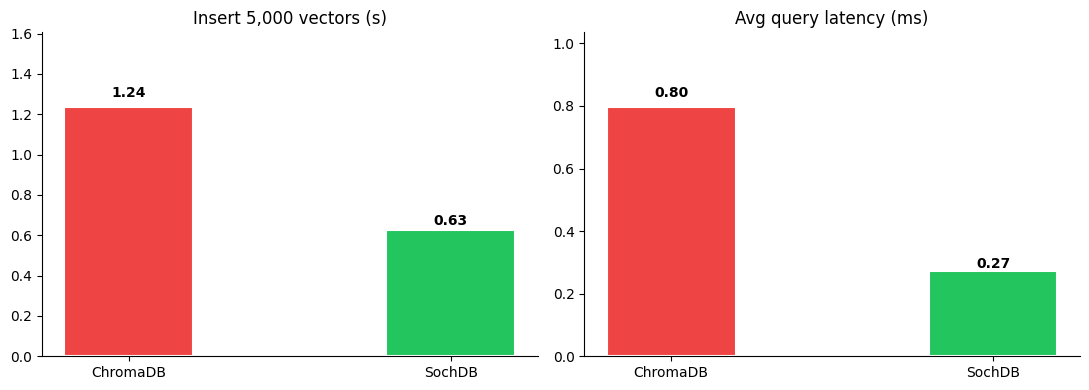

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, labels, vals, title in [
    (axes[0], ['ChromaDB', 'SochDB'], [chroma_t, soch_t], f'Insert {N:,} vectors (s)'),
    (axes[1], ['ChromaDB', 'SochDB'], [chroma_q, soch_q],  'Avg query latency (ms)'),
]:
    bars = ax.bar(labels, vals, color=['#ef4444', '#22c55e'], width=0.4, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v * 1.04, f'{v:.2f}', ha='center', fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('bench_speed.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Test 2 — Search Quality: Hybrid (SochDB) vs Pure Vector (ChromaDB)

5 keyword-trap queries + 1 semantic query.

In [6]:
# ── Wipe any leftover data dirs ───────────────────────────────────────────
for _p in ['./chroma_search', './sochdb_search']:
    if os.path.exists(_p):
        shutil.rmtree(_p)
gc.collect()
time.sleep(0.2)

# ── ChromaDB: fresh isolated client ───────────────────────────────────────
_cc3 = chromadb.PersistentClient(path='./chroma_search')
col_c2 = _cc3.get_or_create_collection('docs', metadata={'hnsw:space': 'cosine'})
col_c2.add(
    ids=[d['id'] for d in DOCUMENTS],
    embeddings=embeddings.tolist(),
    documents=texts,
    metadatas=[{'topic': d['topic']} for d in DOCUMENTS]
)
print(f'ChromaDB : {len(DOCUMENTS)} docs')

# ── SochDB: create namespace + collection ─────────────────────────────────
soch_db = Database.open('./sochdb_search')
soch_db.ffi_namespace_create('research')

with soch_db.use_namespace('research') as ns:
    soch_col = ns.create_collection(
        CollectionConfig(
            name='docs',
            dimension=DIM,
            metric=DistanceMetric.COSINE,
            enable_hybrid_search=True,
            content_field='text',
        )
    )
    soch_col.add(
        ids=[d['id'] for d in DOCUMENTS],
        embeddings=embeddings.tolist(),
        metadatas=[{'topic': d['topic'], 'text': d['text']} for d in DOCUMENTS]
    )
print(f'SochDB   : {len(DOCUMENTS)} docs (hybrid on)')


ChromaDB : 25 docs


NamespaceNotFoundError: [NAMESPACE_NOT_FOUND] Namespace not found: research

In [8]:
import sochdb, pathlib, re

db_text = (pathlib.Path(sochdb.__file__).parent / 'database.py').read_text()

# What key does namespace() look for?
for m in re.finditer(r'marker_key.*\n(?:.*\n){0,5}', db_text):
    print('=== marker_key usage ===')
    print(m.group())
    break

# What does ffi_namespace_create actually write?
for m in re.finditer(r'def ffi_namespace_create.*\n(?:.*\n){0,20}', db_text):
    print('=== ffi_namespace_create ===')
    print(m.group())
    break

# Any pure-python create_namespace?
print('\n=== namespace-related methods on Database ===')
print([x for x in dir(sochdb.Database) if 'namespace' in x.lower()])

=== marker_key usage ===
marker_key = f"_namespaces/{name}/_meta".encode("utf-8")
        import json
        self.put(marker_key, json.dumps(config.to_dict()).encode("utf-8"))
        
        ns = Namespace(self, name, config)
        self._namespaces[name] = ns

=== ffi_namespace_create ===
def ffi_namespace_create(self, name: str) -> None:
        """Create a namespace (FFI-backed, stored in Rust core)."""
        self._check_open()
        res = self._lib.sochdb_namespace_create(
            self._handle, name.encode("utf-8")
        )
        if res != 0:
            raise DatabaseError(f"Failed to create namespace '{name}'")

    def ffi_namespace_delete(self, name: str) -> None:
        """Delete a namespace and all its data (FFI-backed)."""
        self._check_open()
        res = self._lib.sochdb_namespace_delete(
            self._handle, name.encode("utf-8")
        )
        if res != 0:
            raise DatabaseError(f"Failed to delete namespace '{name}'")

    def ffi_n

In [9]:
TEST_QUERIES = [
    {'query': 'GPT-4o multimodal',                      'expected': 'doc_003', 'type': 'keyword'},
    {'query': 'QLoRA 4-bit NormalFloat fine-tuning GPU', 'expected': 'doc_009', 'type': 'keyword'},
    {'query': 'RRF reciprocal rank fusion merging',      'expected': 'doc_013', 'type': 'keyword'},
    {'query': 'UAP universal adversarial perturbation',  'expected': 'doc_024', 'type': 'keyword'},
    {'query': 'Wengrowski Dana CVPR 2019 steganography', 'expected': 'doc_019', 'type': 'keyword'},
    {'query': 'how do large models learn from humans',   'expected': 'doc_007', 'type': 'semantic'},
]

results = []

with soch_db.use_namespace('research') as ns:
    soch_col2 = ns.collection('docs')

    for q in TEST_QUERIES:
        qemb = model.encode(q['query'], normalize_embeddings=True).tolist()

        # ChromaDB — pure vector
        cr = col_c2.query(query_embeddings=[qemb], n_results=3)
        c_top = cr['ids'][0][0] if cr['ids'] and cr['ids'][0] else None

        # SochDB — hybrid (BM25 + vector RRF)
        sr = soch_col2.hybrid_search(vector=qemb, text_query=q['query'], k=3, alpha=0.6)
        # sr may be list of dicts or list of tuples — handle both
        if sr and isinstance(sr[0], dict):
            s_top = sr[0].get('id') or sr[0].get('metadata', {}).get('id')
        elif sr and isinstance(sr[0], (list, tuple)):
            s_top = sr[0][0]
        else:
            s_top = None

        results.append({
            'query':  q['query'],
            'qtype':  q['type'],
            'expected': q['expected'],
            'c_top':  c_top,
            's_top':  s_top,
            'c_hit':  c_top == q['expected'],
            's_hit':  s_top == q['expected'],
        })
        print(f"[{q['type']:7s}] {q['query'][:45]:<45}  chroma={c_top}({'✓' if c_top==q['expected'] else '✗'})  soch={s_top}({'✓' if s_top==q['expected'] else '✗'})")

c_hits = sum(r['c_hit'] for r in results)
s_hits = sum(r['s_hit'] for r in results)
print(f'\nChromaDB hits: {c_hits}/{len(results)}')
print(f'SochDB   hits: {s_hits}/{len(results)}')

# Close ChromaDB client
del col_c2, _cc3
gc.collect()


NamespaceNotFoundError: [NAMESPACE_NOT_FOUND] Namespace not found: research

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

y, w = np.arange(len(results)), 0.35
for i, r in enumerate(results):
    ax1.barh(i - w/2, 1, height=w, color='#22c55e' if r['c_hit'] else '#ef4444', alpha=0.85)
    ax1.barh(i + w/2, 1, height=w, color='#22c55e' if r['s_hit'] else '#ef4444', alpha=0.85)

labels = [f"[{r['qtype']}] {r['query'][:38]}" for r in results]
ax1.set_yticks(y); ax1.set_yticklabels(labels, fontsize=8.5)
ax1.set_xlim(0, 1.5); ax1.set_xticks([])
ax1.set_title('Top-1 hit per query\ntop bar=ChromaDB  bottom bar=SochDB', fontsize=10)
ax1.legend(handles=[
    mpatches.Patch(color='#22c55e', label='Correct'),
    mpatches.Patch(color='#ef4444', label='Wrong'),
], fontsize=9)

ax2.bar(['ChromaDB\n(pure vector)', 'SochDB\n(hybrid RRF)'],
        [c_hits, s_hits],
        color=['#ef4444', '#22c55e'], width=0.4, edgecolor='white', linewidth=1.5)
ax2.set_ylim(0, len(results) + 0.5)
ax2.set_ylabel(f'Hits / {len(results)}', fontsize=11)
ax2.set_title('Total correct (higher = better)', fontsize=11)
for i, v in enumerate([c_hits, s_hits]):
    ax2.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=14)
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('bench_quality.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Test 3 — TOON Token Efficiency

SochDB's TOON format strips repeated JSON keys, giving ~60% token reduction for tabular data in LLM context windows.

In [ ]:
import json as _json

sample_docs = DOCUMENTS[:10]

# JSON format (what ChromaDB returns / everyone hand-rolls)
json_str = _json.dumps(
    [{'id': d['id'], 'topic': d['topic'], 'text': d['text']} for d in sample_docs],
    indent=2
)
json_tok_count = len(enc.encode(json_str))

# TOON format: header line + compact value rows (no repeated keys)
fields = ['id', 'topic', 'text']
toon_lines = [f'docs{len(sample_docs)}' + '{' + ','.join(fields) + '}:']
for d in sample_docs:
    toon_lines.append(','.join(str(d[f]) for f in fields))
toon_str = '\n'.join(toon_lines)
toon_tok_count = len(enc.encode(toon_str))

reduction = (1 - toon_tok_count / json_tok_count) * 100
print(f'JSON tokens : {json_tok_count}')
print(f'TOON tokens : {toon_tok_count}')
print(f'Reduction   : {reduction:.1f}%')
print()
print('--- TOON sample (first 3 rows) ---')
print('\n'.join(toon_lines[:4]))


---
## Summary Dashboard

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Insert speed
ax = axes[0]
bars = ax.bar(['ChromaDB', 'SochDB'], [chroma_t, soch_t],
              color=['#ef4444', '#22c55e'], width=0.45, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, [chroma_t, soch_t]):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.04, f'{v:.1f}s', ha='center', fontweight='bold')
ax.set_title(f'Insert {N:,} vectors', fontsize=12)
ax.set_ylabel('Seconds (lower = better)')
ax.spines[['top','right']].set_visible(False)

# Search quality
ax = axes[1]
bars = ax.bar(['ChromaDB\npure vector', 'SochDB\nhybrid RRF'],
              [c_hits, s_hits],
              color=['#ef4444', '#22c55e'], width=0.45, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, [c_hits, s_hits]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05, str(v), ha='center', fontweight='bold', fontsize=14)
ax.set_ylim(0, len(results) + 1)
ax.set_ylabel(f'Correct / {len(results)} queries')
ax.set_title('Search quality', fontsize=12)
ax.spines[['top','right']].set_visible(False)

# Token efficiency
ax = axes[2]
bars = ax.bar(['JSON\n(ChromaDB)', 'TOON\n(SochDB)'],
              [json_tok_count, toon_tok_count],
              color=['#f97316', '#22c55e'], width=0.45, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, [json_tok_count, toon_tok_count]):
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.04, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Tokens (10 docs)')
ax.set_title(f'Context token efficiency\n({reduction:.0f}% reduction with TOON)', fontsize=12)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('SochDB vs ChromaDB', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bench_summary.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cleanup

In [ ]:
try:
    soch_db.close()
except:
    pass
for _p in ['./chroma_bench', './chroma_search', './sochdb_search', './chroma_data']:
    if os.path.exists(_p):
        shutil.rmtree(_p)
print('All temp data removed.')
